# COMSOL Full-Wave Simulation of a Coupled Quarter-Wave Resonator

::::{admonition} Required extras
:class: tip

This notebook needs the `comsol` extra:

```bash
uv add "qpdk[comsol]"
# or, from a checkout of this repository:
uv sync --extra comsol
# or with pip:
pip install "qpdk[comsol]"
```

Installing the extra installs `MPh`, the Python client for COMSOL, and nothing
else. **It does not install COMSOL and it does not grant a license.** Running
the model build and the full-wave solve needs a local COMSOL installation, a
license, and the RF Module. Google Colab has none of them, so the build cells
cannot run there.

See the {ref}`extras reference <notebook-extras>` for what each extra installs.
::::

This notebook takes a QPDK coupled quarter-wave resonator all the way to a
solved COMSOL model: it prepares the ported layout, builds the sheet model
with air and silicon domains, assigns PEC and numeric TEM ports, adds a
frequency study, solves it, and reads back real field and S-parameter results.

## How this page is published

The figures and numbers on this page are **saved cell outputs**. The numerical
data comes from licensed COMSOL solves; the plotting cells were rerun against
those exports and saved in the committed notebook. The documentation renders
that copy rather than running the cells again.

The whole path is scripted, so a licensed machine reproduces it end to end by
setting `RUN_COMSOL = True`. Without a license the notebook still runs from top
to bottom: the COMSOL cells are skipped, and every cell that reads results
prints how to supply them instead of plotting. On a fresh machine with neither
a license nor exported results you will therefore see the stored figures in the
documentation, but a local run prints skip messages rather than plots. To
replot locally, either export the files with `RUN_COMSOL = True`, or set
`RESULTS_DIR` to a directory that already holds an exported copy.

## What is being modelled

The device is a QPDK
{py:func}`~qpdk.cells.quarter_wave_resonator_coupled`: a meandering
coplanar-waveguide (CPW) resonator placed alongside a straight feedline,
separated by a coupling gap. This is the standard hanger geometry used to read
out superconducting qubits {cite:p}`gopplCoplanarWaveguideResonators2008a`.

Two terminations define a **quarter-wave** resonator:

- The end nearest the feedline is **open**, where the voltage has an antinode.
- The far end is **shorted**, where the current has an antinode.

A line with one open and one shorted end resonates when its electrical length
is an odd multiple of $\lambda/4$. Close to resonance the coupling capacitor
loads the feedline and the transmission $|S_{21}|$ shows a **notch**: at the
resonant frequency, power that would travel from `coupling_o1` to
`coupling_o2` is largely reflected. The centre of the notch gives $f_r$ and
its width the loaded quality factor.

## The model behind the results

COMSOL's own RF example ["Coplanar Waveguide Resonator"](https://www.comsol.com/model/download/953251/models.rf.cpw_resonator.pdf)
is the companion for this geometry. The model built here uses the same stack
and port approach:

1. A silicon block under the metal and an air region above, meeting at the
   metal plane.
2. **PEC on the metal sheets.** The metal is drawn as faces on the
   silicon/air interface rather than as a thin extruded solid, which meshes far
   more reliably for a metal that is three orders of magnitude thinner than the
   substrate.
3. **Numeric TEM ports** on two feed cross sections, each with a **voltage
   integration line** running from ground to the centre conductor. This is the
   usual transmission-line picture, in which the port mode is the quasi-TEM CPW
   mode and the S-parameters come from the travelling-wave amplitudes on the
   feedline {cite:p}`m.pozarMicrowaveEngineering2012`.
4. **Boundary mode analysis** study steps that solve the 2D cross-section
   eigenmode and supply each port's mode field.
5. A **frequency-domain study** over the feedline's transmission band.

Those five steps are what the cells below execute, in this order:

::::{only} html
```{mermaid}
flowchart TB
    A["Ported layout:<br>metal polygons and two open feed planes"]
    B["Sheet model:<br>air above, silicon below, metal faces at z = 0"]
    C["Physics:<br>PEC on the metal, and one numeric TEM port<br>per feed with a voltage integration line"]
    D["Mesh:<br>one automatic size setting"]
    E["Study:<br>one boundary mode analysis per port,<br>then the frequency sweep"]
    F["Results:<br>emw.S21dB, emw.S11dB, and the emw.normE export"]
    A --> B --> C --> D --> E --> F
```
::::

::::{only} typst or typstpdf
The pipeline: ported layout, then the sheet model with air above and silicon
below, then PEC on the metal with one numeric TEM port per feed, then one
automatic mesh size, then a boundary mode analysis per port followed by the
frequency sweep, then the S-parameter and field results.
::::

The outer air and silicon walls use COMSOL's default PEC boundary. This is a
finite conducting enclosure, whereas the reference includes scattering
boundaries. Its influence on the S-parameters has not been converged away.

### What PEC leaves out

The QPDK metal is a superconductor, but this first model treats it as a
perfect electric conductor. PEC has zero surface resistance, so it predicts no
conductor loss, and it ignores the **kinetic inductance** of the film. It is a
useful first approximation for checking geometry, porting, and coupling, but a
measured quality factor cannot be predicted from it. The kinetic inductance
also shifts the resonance. Replacing PEC with a surface-impedance or transition boundary condition
is the next modelling step.

### The ported layout

`prepare_comsol_layout` inverts the M1 etch mask into a ground plane, and the
ground plane then *surrounds* the source feed ports, which sit at $x = 0$ and
$x = 200$ µm inside the prepared bounding box. A port face there would be
buried in ground metal, so those planes cannot be turned into TEM ports.

To expose them, this notebook extends each feed with a straight CPW section to
a plane clear of the whole resonator, then extracts with
`crop_to_feed_ports=True` so both external faces are open CPW cross sections.
**The extension is part of the modelled device**: it lengthens the feedline and
changes the coupling geometry, so the resonance solved here is the resonance of
this extended layout and not the resonance of the unextended reference cell.

### The frequency sweep is not a resonance measurement

The exported S-parameter curve comes from a coarse sweep over 5 to 10 GHz in
steps of 0.25 GHz. A hanger resonator can reach $Q \sim 10^4$ to $10^6$, so its
fractional linewidth can be $10^{-4}$ or smaller, far narrower than the
0.25 GHz spacing. A sweep at this spacing samples the band but **cannot resolve
a notch**, and no resonance frequency or quality factor can be read off it.
Locating $f_r$ that way needs either an eigenfrequency search followed by a
narrow sweep around it, or a much finer grid, plus a mesh refined in the CPW
gaps. The results section below says exactly what the saved data does and does
not show.

::::{admonition} Reading the numbers on this page
:class: warning

The values come from the licensed solves described below, but they are not a
validated device prediction. The metal is a perfect conductor with no surface
resistance or kinetic inductance, the sweep is sparse, and the feed extension
changes the layout. The convergence plots test fixed-frequency S-parameters,
not the resonance frequency or the enclosure boundary.
::::

**References:**
- [COMSOL "Coplanar Waveguide Resonator" model](https://www.comsol.com/model/download/953251/models.rf.cpw_resonator.pdf)
- [COMSOL RF Module User's Guide](https://doc.comsol.com/6.3/doc/com.comsol.help.rf/RFModuleUsersGuide.pdf)
- [COMSOL Reference Manual: Analyzing Model Convergence and Accuracy](https://doc.comsol.com/6.3/doc/com.comsol.help.comsol/comsol_ref_modeling.19.043.html)
- [MPh tutorial](https://mph.readthedocs.io/en/stable/tutorial.html)
- MPh repository: https://github.com/MPh-py/MPh

## Setup and imports

In [1]:
import sys

if "google.colab" in sys.modules:
    import subprocess

    print("Running in Google Colab. Installing QPDK...")
    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "qpdk[comsol] @ git+https://github.com/gdsfactory/quantum-rf-pdk.git",
    ])
    print(
        "Note: this installs the Python client only. COMSOL itself and its "
        "license are not pip-installable, so the build and solve cells below "
        "cannot run in Colab, and the result cells will report that no exported "
        "results are present."
    )

In [2]:
import json
import re
from operator import itemgetter
from pathlib import Path
from typing import Any

import gdsfactory as gf
import matplotlib.pyplot as plt
import numpy as np
from matplotlib import axes as mpl_axes, font_manager
from matplotlib.colors import LogNorm
from matplotlib.patches import Polygon as MplPolygon

from qpdk import PDK
from qpdk.cells.resonator import quarter_wave_resonator_coupled
from qpdk.config import PATH
from qpdk.simulation import (
    add_cpw_rf_study,
    build_comsol_sheet_model,
    prepare_comsol_layout,
)
from qpdk.tech import coplanar_waveguide

try:
    import mph
except ImportError:
    mph = None

PDK.activate()

MPH_AVAILABLE = mph is not None


def _outfit_titles() -> None:
    """Draw plot titles in Outfit bold, matching the documentation headings."""
    original_set_title = mpl_axes.Axes.set_title

    def _set_title(self: mpl_axes.Axes, *args: Any, **kwargs: Any) -> Any:
        kwargs.setdefault("fontfamily", "Outfit")
        kwargs.setdefault("fontweight", "bold")
        return original_set_title(self, *args, **kwargs)

    mpl_axes.Axes.set_title = _set_title


def apply_qpdk_style() -> str:
    """Apply the QPDK plot style, falling back to matplotlib's own defaults.

    The style is ``docs/qpdk.mplstyle`` in a checkout and the installed ``qpdk``
    style in a documentation environment; a downloaded notebook outside both
    keeps matplotlib's defaults instead of failing. The documentation fonts are
    used when they are installed, and matplotlib's bundled families otherwise.

    Returns:
        A short description of the style that was applied.
    """
    for source in (PATH.repo / "docs" / "qpdk.mplstyle", "qpdk"):
        try:
            plt.style.use(source)
        except OSError:
            continue
        applied = str(source)
        break
    else:
        applied = "matplotlib defaults"

    installed = {font.name for font in font_manager.fontManager.ttflist}
    plt.rcParams["font.sans-serif"] = [
        name
        for name in ("Inter", "Outfit", "DejaVu Sans", "Helvetica", "Arial")
        if name in installed
    ] + ["sans-serif"]
    if "Outfit" in installed:
        _outfit_titles()
    return applied


def result_file(name: str) -> Path | None:
    """Return the path of an exported solver result, if one is available.

    Args:
        name: File name to look for inside ``RESULTS_DIR``.

    Returns:
        The path, or ``None`` when ``RESULTS_DIR`` is unset or holds no such file.
    """
    if RESULTS_DIR is None:
        return None
    path = RESULTS_DIR / name
    return path if path.exists() else None


def explain_missing_results(name: str) -> None:
    """Print how to supply a result file that is not on disk.

    Args:
        name: File name that was looked for inside ``RESULTS_DIR``.
    """
    print(
        f"No {name} in RESULTS_DIR ({RESULTS_DIR}). The figures on the "
        "documentation page are saved outputs of a licensed solve, and the cells "
        "here replot only from files on disk. To supply them, run with "
        "RUN_COMSOL = True on a licensed machine, which exports into MODEL_DIR, "
        "or set RESULTS_DIR to a directory that already holds an exported "
        f"{name}."
    )


def exported_frequency_ghz(file: Path) -> float | None:
    """Read the ``@ freq=`` annotation COMSOL writes into a data export header.

    Args:
        file: Exported text file to scan.

    Returns:
        The annotated frequency, in the model's frequency unit (GHz here), or
        ``None`` when the export carries no frequency.
    """
    with file.open(encoding="utf-8") as handle:
        for line in handle:
            if (match := re.search(r"@ freq=([0-9.eE+-]+)", line)) is not None:
                return float(match.group(1))
    return None


STYLE_SOURCE = apply_qpdk_style()
print("Plot style: QPDK" if STYLE_SOURCE != "matplotlib defaults" else STYLE_SOURCE)

Plot style: QPDK


## Build the ported layout

The resonator is created with an explicit CPW cross-section so that the
centre-conductor width and the gap are known constants we reuse when
describing the ports. On the source cell the feed ports `coupling_o1` and
`coupling_o2` sit at $x = 0$ and $x = 200$ µm, well inside the prepared ground
plane. Each is extended to the left and right with a straight CPW of the same
cross-section, so the new feed planes at $x = -300$ µm and $x = 900$ µm are
clear of the resonator and the ground margin.

In [3]:
CPW_WIDTH_UM = 10.0
CPW_GAP_UM = 6.0
LEFT_EXTENSION_UM = 300.0
RIGHT_EXTENSION_UM = 700.0
GROUND_MARGIN_UM = 100.0

cross_section = coplanar_waveguide(width=CPW_WIDTH_UM, gap=CPW_GAP_UM)

resonator = quarter_wave_resonator_coupled(
    length=4000.0,
    meanders=4,
    cross_section=cross_section,
    cross_section_non_resonator=cross_section,
    coupling_straight_length=200.0,
    coupling_gap=20.0,
)

component = gf.Component(name="comsol_cpw_resonator")
component << resonator

left_straight = component << gf.components.straight(
    length=LEFT_EXTENSION_UM, cross_section=cross_section
)
right_straight = component << gf.components.straight(
    length=RIGHT_EXTENSION_UM, cross_section=cross_section
)
left_straight.connect("o2", resonator.ports["coupling_o1"])
right_straight.connect("o1", resonator.ports["coupling_o2"])
component.add_port("input", port=left_straight.ports["o1"])
component.add_port("output", port=right_straight.ports["o2"])

print(f"Extended component: {component.name}")
print(f"Bounding box (µm): {component.bbox()}")
for port in component.ports:
    print(
        f"  {port.name}: center={tuple(round(value, 3) for value in port.center)} µm, "
        f"width={port.width} µm, orientation={port.orientation}°"
    )

Extended component: comsol_cpw_resonator
Bounding box (µm): (-300,-841;900,11)
  input: center=(-300.0, 0.0) µm, width=10.0 µm, orientation=180.0°
  output: center=(900.0, 0.0) µm, width=10.0 µm, orientation=0.0°


In [4]:
layout = prepare_comsol_layout(
    component,
    feed_ports=("input", "output"),
    ground_margin=GROUND_MARGIN_UM,
    crop_to_feed_ports=True,
)

hole_count = sum(len(polygon.holes) for polygon in layout.polygons)
print(f"Metal polygons: {len(layout.polygons)} ({hole_count} holes total)")
print(f"Prepared bounding box (µm): {layout.bbox}")
for feed in layout.feed_ports:
    print(
        f"Feed {feed.name}: center={feed.center} µm, width={feed.width} µm, "
        f"orientation={feed.orientation}°"
    )

Metal polygons: 3 (1 holes total)
Prepared bounding box (µm): ComsolBoundingBox(xmin=-300.0, ymin=-941.0, xmax=900.0, ymax=111.0)
Feed input: center=(-300.0, 0.0) µm, width=10.0 µm, orientation=180.0°
Feed output: center=(900.0, 0.0) µm, width=10.0 µm, orientation=0.0°


The result is three metal polygons with one hole. One polygon is the ground
plane, and the hole is the CPW channel cut through it: the centre-conductor
strip, both etch gaps, and the surrounding ground all come from that one
outline-plus-hole shape. Cropping to the feed planes cut the ground back so
each external face shows an open CPW cross section instead of a wall of
ground, which is what lets the port solver define a mode there.

findfont: Failed to find font weight bold, now using 400.


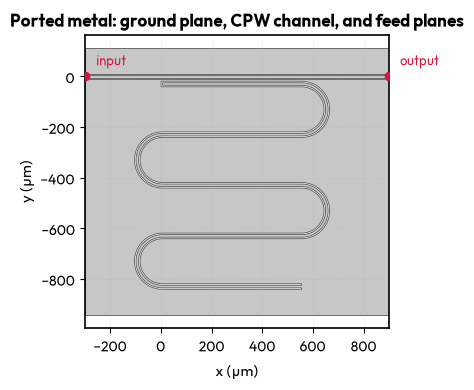

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
for polygon in sorted(
    layout.polygons,
    key=lambda item: (
        -(
            (max(x for x, _ in item.outline) - min(x for x, _ in item.outline))
            * (max(y for _, y in item.outline) - min(y for _, y in item.outline))
        )
    ),
):
    ax.add_patch(
        MplPolygon(
            polygon.outline,
            closed=True,
            facecolor="0.78",
            edgecolor="0.35",
            linewidth=0.6,
            zorder=1,
        )
    )
    for hole in polygon.holes:
        ax.add_patch(
            MplPolygon(
                hole,
                closed=True,
                facecolor="white",
                edgecolor="0.35",
                linewidth=0.6,
                zorder=1,
            )
        )
for feed in layout.feed_ports:
    ax.plot(*feed.center, marker="o", color="crimson", markersize=6, zorder=4)
    ax.annotate(
        feed.name,
        feed.center,
        textcoords="offset points",
        xytext=(8, 8),
        fontsize=9,
        color="crimson",
    )
ax.set_aspect("equal")
ax.set_xlabel("x (µm)")
ax.set_ylabel("y (µm)")
ax.set_title("Ported metal: ground plane, CPW channel, and feed planes")
plt.tight_layout()
plt.show()

## Build the COMSOL model, physics, and study

Three calls turn the layout into a configured model:

- {py:func}`~qpdk.simulation.comsol_sheet.build_comsol_sheet_model` creates the
  air and silicon blocks meeting at $z = 0$, imprints the layout metal on that
  interface as faces, and assigns materials ($\epsilon_r = 1$ air,
  $\epsilon_r = 11.7$ silicon).
- {py:func}`~qpdk.simulation.comsol_rf.add_cpw_rf_study` selects the metal
  faces and applies PEC, adds two numeric TEM ports with voltage integration
  lines spanning the CPW gap, adds the mesh sequence, and adds a study with one
  boundary mode analysis step per port plus a frequency step. Every selection
  is derived from the layout geometry, so no face or edge ID is hard-coded.
- The last calls set the sweep and run it.

The boundary mode steps use 5 GHz as their reference and search near an
effective mode index of 2.5, following the COMSOL CPW reference. The port
mode is then used across the frequency sweep. Check passivity before using
a sweep for design decisions: a passive two-port should have
$|S_{11}|^2 + |S_{21}|^2 \leq 1$ within numerical tolerance.

`mph.start(cores=...)` launches a local COMSOL process and attaches to it.
Only one MPh client can exist per Python process, and the call needs a COMSOL
installation and a license. The whole block is off by default so the notebook
runs without one; set `RUN_COMSOL = True` on a licensed machine to build, solve,
and save the model.

`RUN_MESH_STUDY` turns on the mesh convergence series further down this page.
That series builds and solves one fresh model per mesh size, so it needs
`RUN_COMSOL = True` for the client and it costs a full build and solve per
size. It is off by default.

`RUN_LOCAL_REFINEMENT` turns on a second series further down: the same
automatic size as a base, with a localized refinement of the metal plane
stacked on top. It is a separate control from the automatic size, it also needs
`RUN_COMSOL = True`, and it costs a build and solve per pass. It is off by
default.

`RESULTS_DIR` is where the cells that read results look for exported files. It
defaults to `None` so that a run without a license skips those cells, and to
`MODEL_DIR` when `RUN_COMSOL` is `True`, because the licensed branch below
exports into `MODEL_DIR`. Point it at any directory of exported files to replot
an existing run without starting COMSOL, for example
`RESULTS_DIR = Path("exports")`.

In [6]:
RUN_COMSOL = False
RUN_MESH_STUDY = False  # mesh convergence series below; needs RUN_COMSOL
RUN_LOCAL_REFINEMENT = False  # localized metal-plane refine series; needs RUN_COMSOL
MODEL_DIR = Path.home() / "comsol_models"
MODEL_PATH = MODEL_DIR / "comsol_cpw_resonator.mph"
RESULTS_DIR: Path | None = MODEL_DIR if RUN_COMSOL else None
CORES = 4
SOLVE_FREQUENCY_GHZ = 7.5
MODE_FREQUENCY_GHZ = 5.0
SWEEP_EXPRESSION = "range(5[GHz],0.25[GHz],10[GHz])"

model = None
if RUN_COMSOL and not MPH_AVAILABLE:
    raise RuntimeError("RUN_COMSOL needs MPh and a licensed COMSOL installation")

if RUN_COMSOL and MPH_AVAILABLE:
    MODEL_DIR.mkdir(parents=True, exist_ok=True)
    client = mph.start(cores=CORES)
    model = build_comsol_sheet_model(
        client,
        layout,
        name="QPDK Coupled Quarter-Wave Resonator",
        substrate_thickness_um=200.0,
        air_height_um=200.0,
    )
    add_cpw_rf_study(
        model,
        layout,
        cpw_gap_um=CPW_GAP_UM,
        frequency_ghz=MODE_FREQUENCY_GHZ,
        mesh_size=1,
    )
    model.java.study("std1").feature("freq").set("plist", SWEEP_EXPRESSION)
    model.java.component("comp1").mesh("mesh1").run()
    model.java.study("std1").run()
    model.save(MODEL_PATH)

    solved_frequencies_ghz = np.atleast_1d(model.evaluate("freq")) / 1e9
    solved_s21_db = np.atleast_1d(model.evaluate("emw.S21dB"))
    solved_s11_db = np.atleast_1d(model.evaluate("emw.S11dB"))
    solved_power_sum = 10 ** (solved_s21_db / 10) + 10 ** (solved_s11_db / 10)
    if solved_power_sum.max() > 1.001:
        raise ValueError("The solved sweep violates passive two-port power balance")
    print(f"Solved {solved_frequencies_ghz.size} frequency points")
    print(f"Saved model to {MODEL_PATH}")

    sweep_path = MODEL_DIR / "comsol_cpw_sparameters.csv"
    np.savetxt(
        sweep_path,
        np.column_stack([solved_frequencies_ghz, solved_s21_db, solved_s11_db]),
        delimiter=",",
        header="frequency_ghz,s21_db,s11_db",
        comments="",
    )
    print(f"Saved sweep to {sweep_path}")

    nearest = int(np.argmin(np.abs(solved_frequencies_ghz - SOLVE_FREQUENCY_GHZ)))
    print(
        f"At {solved_frequencies_ghz[nearest]:.2f} GHz: "
        f"S21 = {solved_s21_db[nearest]:+.3f} dB, "
        f"S11 = {solved_s11_db[nearest]:+.3f} dB"
    )

A single-point solve is a useful check against the matching sweep point. In a
controlled rerun with the same mesh and boundary-mode settings, the two agreed
within numerical precision. That check guards against a study configuration
mismatch; it does not establish mesh or domain convergence.

### Exporting a field map

The electric-field map shown further down this page was written from the
solved model with COMSOL's Data export on a cut plane at $z = 1$ µm, exported
at the sweep point nearest 7.5 GHz. The same export is scripted below: a
`CutPlane` dataset over the $xy$ plane, then a `Data` result export with the
expression `emw.normE`. It runs inside the licensed branch, next to the solve,
and writes into `MODEL_DIR`, where `RESULTS_DIR` picks it up.

In [7]:
if RUN_COMSOL and MPH_AVAILABLE and model is not None:
    plane = model.java.result().dataset().create("cutplane", "CutPlane")
    plane.set("planetype", "quick")
    plane.set("quickplane", "xy")
    plane.set("quickz", "1[um]")
    plane.set("data", "dset1")

    field_export = model.java.result().export().create("field", "Data")
    field_export.set("data", "cutplane")
    field_export.set("expr", ["emw.normE"])
    field_export.set("innerinput", "manual")
    field_export.set("solnum", str(nearest + 1))
    field_export.set("filename", str(MODEL_DIR / "comsol_cpw_field.txt"))
    field_export.run()
    print(f"Exported emw.normE to {MODEL_DIR / 'comsol_cpw_field.txt'}")

## Transmission sweep

This cell replots the exported sweep `frequency_ghz, s21_db, s11_db`. The curve
saved as an output of this cell was produced by the sweep configured above. It
is a transmission snapshot of the ported feedline, not a resonance measurement:
no notch is resolved. A narrow feature could fall between the sampled points,
but these results do not establish that a mode lies in this band. The values
are real solver output at each sweep point; they do not establish $f_r$ or $Q$.

With `RESULTS_DIR` unset, or set to a directory without the export, the cell
prints how to supply the file and draws nothing.

Sweep points: 21, 5.00 to 10.00 GHz
At 7.50 GHz: S21 = -0.006 dB, S11 = -28.408 dB
Scan of the band: S21 from -0.010 to -0.003 dB, S11 from -31.706 to -26.208 dB
Largest |S11|² + |S21|² = 1.000148


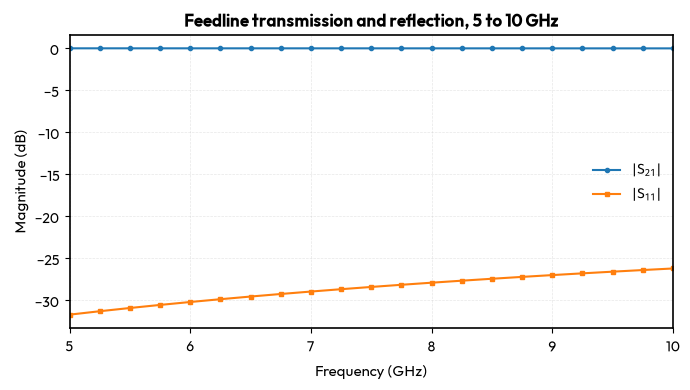

In [8]:
SWEEP_CSV = "comsol_cpw_sparameters.csv"
sweep_file = result_file(SWEEP_CSV)

if sweep_file is None:
    explain_missing_results(SWEEP_CSV)
else:
    SPARAMETERS = np.atleast_1d(np.genfromtxt(sweep_file, delimiter=",", names=True))
    sweep_ghz = SPARAMETERS["frequency_ghz"]
    sweep_s21_db = SPARAMETERS["s21_db"]
    sweep_s11_db = SPARAMETERS["s11_db"]
    power_sum = 10 ** (sweep_s21_db / 10) + 10 ** (sweep_s11_db / 10)
    if power_sum.max() > 1.001:
        raise ValueError("The saved sweep violates passive two-port power balance")

    nearest = int(np.argmin(np.abs(sweep_ghz - SOLVE_FREQUENCY_GHZ)))
    print(
        f"Sweep points: {sweep_ghz.size}, "
        f"{sweep_ghz.min():.2f} to {sweep_ghz.max():.2f} GHz"
    )
    print(
        f"At {sweep_ghz[nearest]:.2f} GHz: "
        f"S21 = {sweep_s21_db[nearest]:+.3f} dB, "
        f"S11 = {sweep_s11_db[nearest]:+.3f} dB"
    )
    print(
        "Scan of the band: "
        f"S21 from {sweep_s21_db.min():+.3f} to {sweep_s21_db.max():+.3f} dB, "
        f"S11 from {sweep_s11_db.min():+.3f} to {sweep_s11_db.max():+.3f} dB"
    )
    print(f"Largest |S11|² + |S21|² = {power_sum.max():.6f}")

    fig, ax = plt.subplots(figsize=(7, 4))
    ax.plot(sweep_ghz, sweep_s21_db, marker="o", markersize=3, label=r"$|S_{21}|$")
    ax.plot(sweep_ghz, sweep_s11_db, marker="s", markersize=3, label=r"$|S_{11}|$")
    ax.set_xlabel("Frequency (GHz)")
    ax.set_ylabel("Magnitude (dB)")
    ax.set_title(
        "Feedline transmission and reflection, "
        f"{sweep_ghz.min():g} to {sweep_ghz.max():g} GHz"
    )
    ax.grid(True)
    ax.legend()
    plt.tight_layout()
    plt.show()

The curve varies smoothly by a fraction of a dB across the band. That is the
compatible with a feedline sampled away from a narrow feature, but the data
cannot distinguish a missed narrow mode from a mode outside this band or a
setup error. An eigenfrequency search and a narrower sweep can investigate
that question. Any identified notch also needs mesh and domain checks before
its frequency and depth can be trusted.

## Field map

The exported field is the electric-field norm on the $z = 1$ µm plane at the
exported frequency, read from the export's own `@ freq=` annotation rather than
assumed. The metal sheet lies at $z = 0$ and the plane sits just above it, so
the map shows the modal field in the CPW gaps and along the resonator. This
sweep map uses automatic mesh size 1; the separately refined map below is
more resolved near the metal.

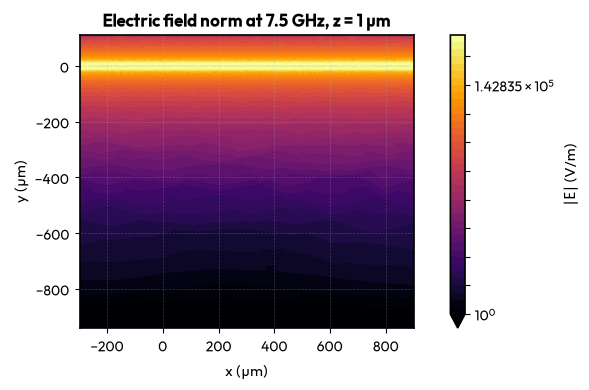

In [9]:
FIELD_TXT = "comsol_cpw_field.txt"
field_file = result_file(FIELD_TXT)

if field_file is None:
    explain_missing_results(FIELD_TXT)
else:
    field = np.loadtxt(field_file, comments="%")
    field_x, field_y, field_e = field[:, 0], field[:, 1], field[:, 3]

    field_frequency_ghz = exported_frequency_ghz(field_file)
    frequency_label = (
        f"{field_frequency_ghz:g} GHz, " if field_frequency_ghz is not None else ""
    )

    fig, ax = plt.subplots(figsize=(8, 4))
    contour = ax.tricontourf(
        field_x,
        field_y,
        field_e,
        levels=np.geomspace(1.0, field_e.max(), 40),
        norm=LogNorm(vmin=1.0, vmax=field_e.max()),
        cmap="inferno",
        extend="min",
    )
    ax.set_aspect("equal")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(f"Electric field norm at {frequency_label}z = 1 µm")
    fig.colorbar(contour, ax=ax, label=r"$|\mathbf{E}|$ (V/m)")
    plt.tight_layout()
    plt.show()

The field concentrates in the narrow CPW gaps and at the ends of the metal
edges, where the surface charge collects. That localisation is why the mesh has
to be refined in the gaps before the notch position is trusted: an
under-resolved gap smears the field and shifts the resonance.

## Mesh convergence study

A mesh convergence study re-solves one and the same model with everything held
fixed except the element size, and watches how the quantity of interest moves
as the mesh is refined. That is the only evidence a discretised number is set
by the physics rather than by the mesh, and COMSOL's own guidance on running
and reading one is in
[Analyzing Model Convergence and Accuracy](https://doc.comsol.com/6.3/doc/com.comsol.help.comsol/comsol_ref_modeling.19.043.html).

The series below varies `mesh_size` alone, from 8 down to 1, and builds a
fresh model for every size. The layout, the air and silicon thicknesses, the
CPW gap, the 5 GHz boundary-mode reference, and the 7.5 GHz solve point are the
same arguments the solve above uses, so the mesh is the only thing that
changes. Each row records the mesh element count from `getNumElem` and the
S-parameter magnitudes at that frequency. A controlled check at the same mesh
found that the single-frequency solve and the matching sweep point agree.

### What a converged S-parameter does and does not establish

If $S_{21}$ and $S_{11}$ at 7.5 GHz stop moving as the element count grows,
then those two numbers at that one frequency are no longer mesh-limited. That
is all it establishes. A **fixed-frequency S-parameter converging does not
prove** that the resonance frequency has converged, that the peak field in the
CPW gaps has converged, or that the outer PEC walls have stopped influencing
the answer. Those are different quantities: $f_r$ comes from where a notch
sits rather than from the value at one frequency and can drift while that value
holds still; a field maximum is especially sensitive to sharp metal edges;
and the boundary walls are fixed geometry, so no amount of
mesh refinement removes their effect. Each needs its own refinement study, and
the coarse sweep on this page cannot resolve $f_r$ at all.

The series is off by default. Set `RUN_MESH_STUDY = True` alongside
`RUN_COMSOL = True`; it reuses the client the licensed branch already started,
because only one MPh client can exist per Python process. A mesh size that
fails to mesh or solve is printed in full and left out of the table, so a gap
in the series is visible rather than silently dropped. The JSON holds the rows
and the sizes that failed, nothing else.

In [10]:
CPW_MESH_SIZES = (8, 7, 6, 5, 4, 3, 2, 1)
MESH_JSON = "comsol_mesh_convergence.json"
MESH_KEY = "cpw_mesh_convergence"


def mesh_element_count(model: Any) -> int:
    """Return the number of mesh elements in a model's mesh.

    Args:
        model: A built and meshed MPh model.

    Returns:
        The number of mesh elements.
    """
    return int(model.java.component("comp1").mesh("mesh1").getNumElem())


def run_cpw_mesh_size(client: Any, size: int) -> dict[str, Any]:
    """Build, mesh, and solve one mesh size, and return its convergence row.

    The model is built from scratch so nothing carries over from another size,
    and it is removed from the client even when the mesh or the solve raises.

    Args:
        client: The MPh client the licensed branch already started.
        size: COMSOL mesh size, 1 (finest) to 9 (coarsest).

    Returns:
        A row holding the mesh size, the mesh element count, and the S-parameter
        magnitudes at ``SOLVE_FREQUENCY_GHZ``.
    """
    temp_model = build_comsol_sheet_model(
        client,
        layout,
        name=f"QPDK CPW mesh size {size}",
        substrate_thickness_um=200.0,
        air_height_um=200.0,
    )
    try:
        add_cpw_rf_study(
            temp_model,
            layout,
            cpw_gap_um=CPW_GAP_UM,
            frequency_ghz=MODE_FREQUENCY_GHZ,
            mesh_size=size,
        )
        temp_model.java.study("std1").feature("freq").set(
            "plist", f"{SOLVE_FREQUENCY_GHZ}[GHz]"
        )
        temp_model.java.component("comp1").mesh("mesh1").run()
        element_count = mesh_element_count(temp_model)
        temp_model.java.study("std1").run()
        for problem in temp_model.problems():
            print(f"  mesh size {size} reports: {problem}")
        return {
            "mesh_size": size,
            "frequency_ghz": SOLVE_FREQUENCY_GHZ,
            "element_count": element_count,
            "s21_db_at_target": float(
                np.atleast_1d(temp_model.evaluate("emw.S21dB"))[0]
            ),
            "s11_db_at_target": float(
                np.atleast_1d(temp_model.evaluate("emw.S11dB"))[0]
            ),
        }
    finally:
        client.remove(temp_model)


if RUN_COMSOL and MPH_AVAILABLE and RUN_MESH_STUDY:
    rows: list[dict[str, Any]] = []
    failures: list[dict[str, Any]] = []

    for size in CPW_MESH_SIZES:
        print(f"Mesh size {size}: building, meshing, and solving")
        try:
            row = run_cpw_mesh_size(client, size)
        except Exception as error:
            failures.append({"mesh_size": size, "error": type(error).__name__})
            print(f"Mesh size {size} FAILED: {type(error).__name__}: {error}")
            continue
        rows.append(row)
        print(
            f"Mesh size {size}: {row['element_count']} elements, "
            f"S21 = {row['s21_db_at_target']:+.4f} dB, "
            f"S11 = {row['s11_db_at_target']:+.4f} dB"
        )

    mesh_path = MODEL_DIR / MESH_JSON
    try:
        mesh_payload = json.loads(mesh_path.read_text())
    except FileNotFoundError:
        mesh_payload = {}
    mesh_payload[MESH_KEY] = rows
    if failures:
        mesh_payload[f"{MESH_KEY}_failures"] = failures
    else:
        mesh_payload.pop(f"{MESH_KEY}_failures", None)
    mesh_path.write_text(json.dumps(mesh_payload, indent=2) + "\n")
    print(f"Wrote {len(rows)} of {len(CPW_MESH_SIZES)} rows to {mesh_path}")
    if failures:
        failed_sizes = ", ".join(str(item["mesh_size"]) for item in failures)
        print(f"No row was written for mesh sizes: {failed_sizes}")
elif RUN_MESH_STUDY and not RUN_COMSOL:
    print(
        "RUN_MESH_STUDY needs RUN_COMSOL = True: the series reuses the COMSOL "
        "client that the licensed branch starts."
    )

### Reading the convergence table

The cell below replots those rows: the S-parameter magnitudes against the 3D
element count, each point labelled with its mesh size (1 is the finest mesh, 8
the coarsest), with the change from one mesh to the next printed underneath.
Differences that shrink as the mesh refines are the shape a settled number
makes; differences that keep their size, or change sign, mean the quantity is
still moving with the mesh. Whatever the table shows, it is evidence about
$S_{21}$ and $S_{11}$ at 7.5 GHz only, for the reasons in the section above.

With `RESULTS_DIR` unset, or set to a directory without the file, the cell
prints how to supply it and draws nothing.

mesh   elements   S21 (dB)      dS21   S11 (dB)      dS11
   8       1969    -0.2511             -12.5104          
   7       3285    -0.1338   +0.1173   -15.1764   -2.6660
   6       4767    -0.0767   +0.0571   -17.5647   -2.3883
   5       9655    -0.0496   +0.0271   -19.4525   -1.8878
   4      21328    -0.0234   +0.0262   -22.6726   -3.2202
   3      41629    -0.0102   +0.0132   -26.2768   -3.6042
   2      60034    -0.0069   +0.0033   -27.8281   -1.5512
   1      85421    -0.0060   +0.0009   -28.4075   -0.5795


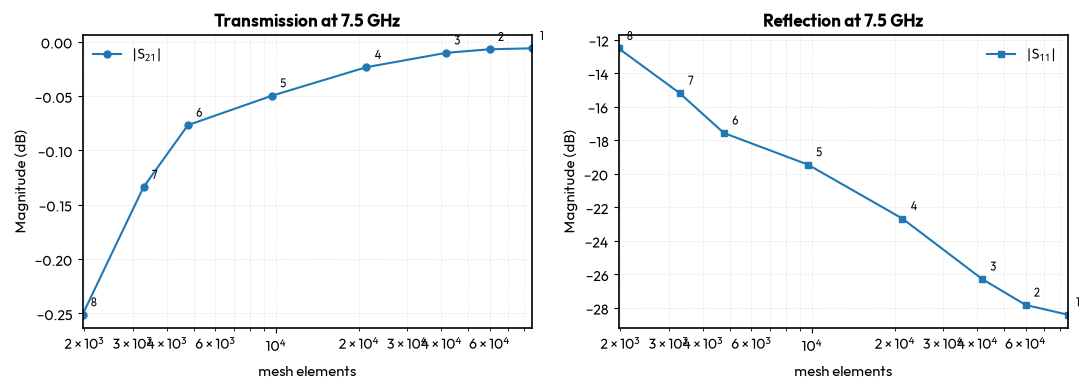

In [11]:
mesh_file = result_file(MESH_JSON)

if mesh_file is None:
    explain_missing_results(MESH_JSON)
else:
    mesh_payload = json.loads(mesh_file.read_text())
    rows = mesh_payload.get(MESH_KEY) or []
    for failure in mesh_payload.get(f"{MESH_KEY}_failures") or []:
        print(f"Mesh size {failure['mesh_size']} failed: {failure['error']}")
    if not rows:
        explain_missing_results(MESH_JSON)
        print(f"The file on disk carries no {MESH_KEY} rows.")
    else:
        rows = sorted(rows, key=itemgetter("element_count"))
        element_counts = np.array([row["element_count"] for row in rows], dtype=float)
        mesh_sizes = [int(row["mesh_size"]) for row in rows]
        s21_db = np.array([row["s21_db_at_target"] for row in rows], dtype=float)
        s11_db = np.array([row["s11_db_at_target"] for row in rows], dtype=float)
        frequencies_ghz = {float(row["frequency_ghz"]) for row in rows}
        if len(frequencies_ghz) != 1:
            raise ValueError("Mesh rows have different solved frequencies")
        solved_frequency_ghz = frequencies_ghz.pop()

        print(
            f"{'mesh':>4} {'elements':>10} {'S21 (dB)':>10} {'dS21':>9} "
            f"{'S11 (dB)':>10} {'dS11':>9}"
        )
        for index, row in enumerate(rows):
            s21_step = (
                "" if index == 0 else f"{s21_db[index] - s21_db[index - 1]:>+9.4f}"
            )
            s11_step = (
                "" if index == 0 else f"{s11_db[index] - s11_db[index - 1]:>+9.4f}"
            )
            print(
                f"{row['mesh_size']:>4} {row['element_count']:>10} "
                f"{s21_db[index]:>+10.4f} {s21_step:>9} "
                f"{s11_db[index]:>+10.4f} {s11_step:>9}"
            )

        fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
        for axis, values, label, marker in (
            (axes[0], s21_db, r"$|S_{21}|$", "o"),
            (axes[1], s11_db, r"$|S_{11}|$", "s"),
        ):
            axis.plot(element_counts, values, marker=marker, markersize=5, label=label)
            for x, y, size in zip(element_counts, values, mesh_sizes, strict=True):
                axis.annotate(
                    str(size),
                    (x, y),
                    textcoords="offset points",
                    xytext=(6, 6),
                    fontsize=8,
                )
            axis.set_xscale("log")
            axis.set_xlabel("mesh elements")
            axis.set_ylabel("Magnitude (dB)")
            axis.grid(True, which="both", alpha=0.3)
            axis.legend()
        axes[0].set_title(f"Transmission at {solved_frequency_ghz:g} GHz")
        axes[1].set_title(f"Reflection at {solved_frequency_ghz:g} GHz")
        plt.tight_layout()
        plt.show()

### Localized metal-plane refinement

The series above moves one control: COMSOL's overall automatic mesh size, which
scales the element size over the whole model. A second and separate control is
to keep that automatic size as the base and refine only where the field is
known to be concentrated. The series below does that. Each pass is built at
automatic size 2, meshed, and then a refinement feature restricted to a box
around the metal plane is added and the mesh is run again.

**A pass here is a mesh refinement pass, not a solver iteration.** It is one
application of the refinement feature to the mesh. It is not a Newton or other
nonlinear iteration, and nothing about the solver's own convergence is read
from the pass number.

The box spans the whole prepared layout in $x$ and $y$ and runs from
$z = -20$ to $+20$ µm, so it contains the metal sheet and the CPW gaps beside
it, where the field concentrates. Each pass refines the elements whose corners
lie inside the box, splitting their longest edge. Elements just outside can be
pulled in by the conforming mesh, so the element count is not only the elements
of the box.

The local refinement and the automatic-size series are **separate controls**,
not two dials on one thing: the automatic size sets the base element size
everywhere, and the refinement changes a subregion of that base. A settled
local-refinement series and a settled automatic-size series are therefore
different statements about the model, and neither one establishes the other.

Pass 0 is the automatic size 2 mesh with no refinement, the same base the
series above records, so the refined passes are read as a change from it. The
caution from the section above carries over unchanged: a settled $S_{21}$ at
7.5 GHz is a settled *fixed-frequency* number, and it is **not** evidence that
the resonance frequency, the peak gap field, or the wall-boundary effect has
converged. $f_r$ comes from where a notch sits rather than from the value at
one frequency, and the coarse sweep on this page cannot resolve a notch at all.

The series is off by default. Set `RUN_LOCAL_REFINEMENT = True` alongside
`RUN_COMSOL = True`; it reuses the client the licensed branch already started,
because only one MPh client can exist per Python process. It costs a build, a
mesh, and a solve per pass. A pass that fails to mesh or solve is printed in
full and left out of the table, and the passes that failed are kept in the JSON
next to the rows that were written, so a gap in the series is visible rather
than silently dropped.

In [12]:
LOCAL_BASE_MESH_SIZE = 2
LOCAL_REFINE_PASSES = (0, 1, 2, 3, 4)
LOCAL_BOX_Z_UM = 20.0
LOCAL_MESH_KEY = "cpw_local_refine"


def compact_element_count(count: int) -> str:
    """Format an element count for a plot label.

    Args:
        count: Number of mesh elements.

    Returns:
        The count in thousands, or the plain count below ten thousand.
    """
    return f"{count / 1e3:.0f}k" if count >= 10_000 else f"{count:,}"


def run_cpw_refine_pass(client: Any, passes: int) -> dict[str, Any]:
    """Build, locally refine, and solve one refinement pass.

    The model is built from scratch at ``LOCAL_BASE_MESH_SIZE`` and meshed once,
    so the refinement lays on top of the automatic size instead of replacing it.
    The model is removed from the client even when the mesh or the solve raises.

    Args:
        client: The MPh client the licensed branch already started.
        passes: Number of refinement passes to apply.

    Returns:
        A row holding the pass count, the mesh element count, and the S-parameter
        magnitudes at ``SOLVE_FREQUENCY_GHZ``.

    Raises:
        RuntimeError: The refined mesh has no mesh elements.
    """
    temp_model = build_comsol_sheet_model(
        client,
        layout,
        name=f"QPDK CPW refine passes {passes}",
        substrate_thickness_um=200.0,
        air_height_um=200.0,
    )
    try:
        add_cpw_rf_study(
            temp_model,
            layout,
            cpw_gap_um=CPW_GAP_UM,
            frequency_ghz=MODE_FREQUENCY_GHZ,
            mesh_size=LOCAL_BASE_MESH_SIZE,
        )
        temp_model.java.study("std1").feature("freq").set(
            "plist", f"{SOLVE_FREQUENCY_GHZ}[GHz]"
        )
        mesh = temp_model.java.component("comp1").mesh("mesh1")
        mesh.run()
        # Refine switches the sequence to user-controlled, so retain a generator.
        mesh.create("ftet_refine", "FreeTet")
        if passes:
            refine = mesh.create("ref1", "Refine")
            refine.set("numrefine", passes)
            refine.set("rmethod", "longest")
            refine.set("boxcoord", "on")
            refine.set("xmin", f"{layout.bbox.xmin}[um]")
            refine.set("xmax", f"{layout.bbox.xmax}[um]")
            refine.set("ymin", f"{layout.bbox.ymin}[um]")
            refine.set("ymax", f"{layout.bbox.ymax}[um]")
            refine.set("zmin", f"{-LOCAL_BOX_Z_UM}[um]")
            refine.set("zmax", f"{LOCAL_BOX_Z_UM}[um]")
        mesh.run()
        element_count = mesh_element_count(temp_model)
        if element_count == 0:
            raise RuntimeError("The refinement sequence produced no mesh elements")
        temp_model.java.study("std1").run()
        for problem in temp_model.problems():
            print(f"  refine passes {passes} reports: {problem}")
        if passes == max(LOCAL_REFINE_PASSES):
            plane = (
                temp_model.java.result().dataset().create("refined_plane", "CutPlane")
            )
            plane.set("planetype", "quick")
            plane.set("quickplane", "xy")
            plane.set("quickz", "1[um]")
            plane.set("data", "dset1")
            field_export = (
                temp_model.java.result().export().create("refined_field", "Data")
            )
            field_export.set("data", "refined_plane")
            field_export.set("expr", ["emw.normE"])
            field_export.set(
                "filename", str(MODEL_DIR / "comsol_cpw_refined_field.txt")
            )
            field_export.run()
            (MODEL_DIR / "comsol_cpw_refined_field.json").write_text(
                json.dumps(
                    {
                        "refine_passes": passes,
                        "element_count": element_count,
                        "frequency_ghz": SOLVE_FREQUENCY_GHZ,
                    },
                    indent=2,
                )
                + "\n"
            )
        return {
            "refine_passes": passes,
            "frequency_ghz": SOLVE_FREQUENCY_GHZ,
            "element_count": element_count,
            "s21_db_at_target": float(
                np.atleast_1d(temp_model.evaluate("emw.S21dB"))[0]
            ),
            "s11_db_at_target": float(
                np.atleast_1d(temp_model.evaluate("emw.S11dB"))[0]
            ),
        }
    finally:
        client.remove(temp_model)


if RUN_COMSOL and MPH_AVAILABLE and RUN_LOCAL_REFINEMENT:
    (MODEL_DIR / "comsol_cpw_refined_field.txt").unlink(missing_ok=True)
    (MODEL_DIR / "comsol_cpw_refined_field.json").unlink(missing_ok=True)
    refine_path = MODEL_DIR / MESH_JSON
    try:
        refine_payload = json.loads(refine_path.read_text())
    except FileNotFoundError:
        refine_payload = {}

    refine_rows: list[dict[str, Any]] = []
    refine_failures: list[dict[str, Any]] = []
    for passes in LOCAL_REFINE_PASSES:
        print(f"Refine passes {passes}: building, refining, and solving")
        try:
            row = run_cpw_refine_pass(client, passes)
        except Exception as error:
            refine_failures.append({
                "refine_passes": passes,
                "error": type(error).__name__,
            })
            print(f"Refine passes {passes} FAILED: {type(error).__name__}: {error}")
            continue
        refine_rows.append(row)
        print(
            f"Refine passes {passes}: {row['element_count']} elements, "
            f"S21 = {row['s21_db_at_target']:+.4f} dB, "
            f"S11 = {row['s11_db_at_target']:+.4f} dB"
        )

    refine_payload[LOCAL_MESH_KEY] = refine_rows
    if refine_failures:
        refine_payload[f"{LOCAL_MESH_KEY}_failures"] = refine_failures
    else:
        refine_payload.pop(f"{LOCAL_MESH_KEY}_failures", None)
    refine_path.write_text(json.dumps(refine_payload, indent=2) + "\n")
    print(f"Wrote {len(refine_rows)} rows to {refine_path}")
    if refine_failures:
        failed_passes = ", ".join(
            str(item["refine_passes"]) for item in refine_failures
        )
        print(f"No row was written for refine passes: {failed_passes}")
elif RUN_LOCAL_REFINEMENT and not RUN_COMSOL:
    print(
        "RUN_LOCAL_REFINEMENT needs RUN_COMSOL = True: the series reuses the "
        "COMSOL client that the licensed branch starts."
    )

### Reading the localized refinement series

The cell below replots those passes: the S-parameter magnitudes at 7.5 GHz
against the pass number, each point labelled with its mesh element count, with
the change from one pass to the next printed underneath. A pass is joined to
the next only when both are present, so a pass with no row breaks the line
instead of a line being drawn across the gap. Differences that shrink as the
passes increase are the shape a settled number makes; differences that keep
their size, or change sign, mean the quantity is still moving with the mesh.
Whatever the table shows, it is evidence about $S_{21}$ and $S_{11}$ at 7.5 GHz
only, for the reasons in the sections above.
The printed 0.001 dB and 0.1 dB last-step thresholds are illustrative
stopping criteria for these fixed-frequency values, not error bounds.

With `RESULTS_DIR` unset, or set to a directory without the file, the cell
prints how to supply it and draws nothing.

pass   elements   S21 (dB)      dS21   S11 (dB)      dS11
   0      60034    -0.0069             -27.8281          
   1     129649    -0.0034   +0.0036   -31.3538   -3.5257
   2     350907    -0.0013   +0.0021   -34.7820   -3.4282
   3    1054708    -0.0008   +0.0005   -38.8232   -4.0412
   4    3182249    +0.0001   +0.0009   -42.8508   -4.0275
Last consecutive-pass changes: S21 0.0009 dB (below 0.001 dB: True); S11 4.0275 dB (below 0.1 dB: False)


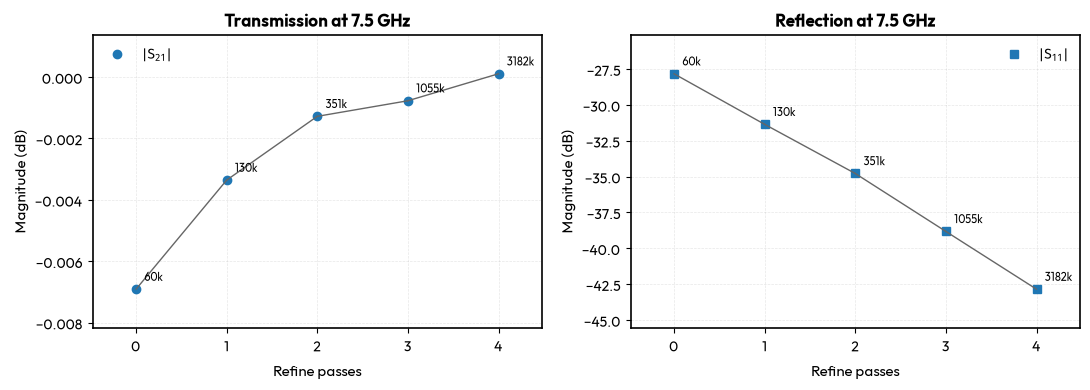

In [13]:
refine_file = result_file(MESH_JSON)

if refine_file is None:
    explain_missing_results(MESH_JSON)
else:
    refine_payload = json.loads(refine_file.read_text())
    refine_rows = refine_payload.get(LOCAL_MESH_KEY) or []
    refine_failures = refine_payload.get(f"{LOCAL_MESH_KEY}_failures") or []
    for failure in refine_failures:
        print(f"Refine passes {failure['refine_passes']} failed: {failure['error']}")
    if not refine_rows:
        explain_missing_results(MESH_JSON)
        print(f"The file on disk carries no {LOCAL_MESH_KEY} rows.")
    else:
        refine_rows = sorted(refine_rows, key=itemgetter("refine_passes"))
        passes = np.array([row["refine_passes"] for row in refine_rows], dtype=int)
        element_counts = np.array(
            [row["element_count"] for row in refine_rows], dtype=float
        )
        s21_db = np.array([row["s21_db_at_target"] for row in refine_rows], dtype=float)
        s11_db = np.array([row["s11_db_at_target"] for row in refine_rows], dtype=float)
        frequencies_ghz = {float(row["frequency_ghz"]) for row in refine_rows}
        if len(frequencies_ghz) != 1:
            raise ValueError("Refinement rows have different solved frequencies")
        solved_frequency_ghz = frequencies_ghz.pop()

        print(
            f"{'pass':>4} {'elements':>10} {'S21 (dB)':>10} {'dS21':>9} "
            f"{'S11 (dB)':>10} {'dS11':>9}"
        )
        for index, row in enumerate(refine_rows):
            consecutive = index > 0 and passes[index] == passes[index - 1] + 1
            s21_step = (
                f"{s21_db[index] - s21_db[index - 1]:>+9.4f}" if consecutive else ""
            )
            s11_step = (
                f"{s11_db[index] - s11_db[index - 1]:>+9.4f}" if consecutive else ""
            )
            print(
                f"{row['refine_passes']:>4} {row['element_count']:>10} "
                f"{s21_db[index]:>+10.4f} {s21_step:>9} "
                f"{s11_db[index]:>+10.4f} {s11_step:>9}"
            )

        if len(refine_rows) >= 2 and passes[-1] == passes[-2] + 1:
            s21_change = abs(s21_db[-1] - s21_db[-2])
            s11_change = abs(s11_db[-1] - s11_db[-2])
            print(
                "Last consecutive-pass changes: "
                f"S21 {s21_change:.4f} dB (below 0.001 dB: {s21_change < 0.001}); "
                f"S11 {s11_change:.4f} dB (below 0.1 dB: {s11_change < 0.1})"
            )

        present_passes = set(passes)
        missing_passes = [
            number
            for number in range(int(passes.min()), int(passes.max()) + 1)
            if number not in present_passes
        ]
        if missing_passes:
            missing = ", ".join(str(number) for number in missing_passes)
            print(f"No row for refine passes: {missing}")

        fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharex=True)
        for axis, values, label, marker in (
            (axes[0], s21_db, r"$|S_{21}|$", "o"),
            (axes[1], s11_db, r"$|S_{11}|$", "s"),
        ):
            axis.plot(
                passes,
                values,
                linestyle="none",
                marker=marker,
                markersize=6,
                label=label,
            )
            for index in range(passes.size - 1):
                if passes[index + 1] == passes[index] + 1:
                    axis.plot(
                        passes[index : index + 2],
                        values[index : index + 2],
                        color="0.4",
                        linewidth=1.0,
                    )
            for x, y, count in zip(passes, values, element_counts, strict=True):
                axis.annotate(
                    compact_element_count(int(count)),
                    (x, y),
                    textcoords="offset points",
                    xytext=(6, 6),
                    fontsize=8,
                )
            axis.set_xticks(range(int(passes.min()), int(passes.max()) + 1))
            axis.margins(x=0.12, y=0.18)
            axis.set_xlabel("Refine passes")
            axis.set_ylabel("Magnitude (dB)")
            axis.grid(True, alpha=0.3)
            axis.legend()
        axes[0].set_title(f"Transmission at {solved_frequency_ghz:g} GHz")
        axes[1].set_title(f"Reflection at {solved_frequency_ghz:g} GHz")
        plt.tight_layout()
        plt.show()

### Field on the locally refined mesh

This is the cut-plane field from the last refinement pass above, solved at
7.5 GHz. It uses a finer mesh around the metal plane than the sweep map shown
earlier. A sharper edge field here does not establish convergence of the
maximum field or locate a resonance.

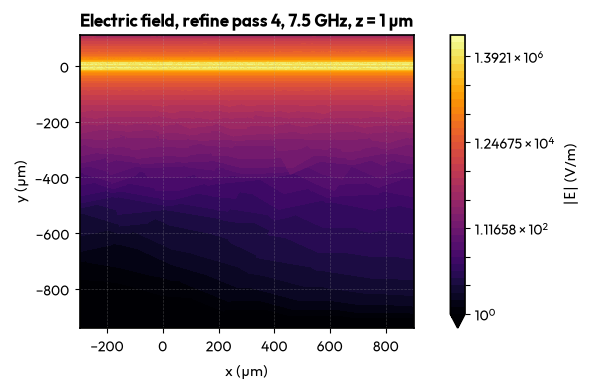

In [14]:
refined_field_file = result_file("comsol_cpw_refined_field.txt")
refined_field_meta_file = result_file("comsol_cpw_refined_field.json")
refined_mesh_file = result_file(MESH_JSON)
if (
    refined_field_file is None
    or refined_field_meta_file is None
    or refined_mesh_file is None
):
    explain_missing_results("comsol_cpw_refined_field.txt")
else:
    field_meta = json.loads(refined_field_meta_file.read_text())
    field_pass = int(field_meta["refine_passes"])
    matching_rows = [
        row
        for row in json.loads(refined_mesh_file.read_text()).get(LOCAL_MESH_KEY, [])
        if row["refine_passes"] == field_pass
    ]
    if (
        len(matching_rows) != 1
        or matching_rows[0]["element_count"] != field_meta["element_count"]
    ):
        raise ValueError("Refined field metadata does not match a solved mesh row")
    refined_field = np.loadtxt(refined_field_file, comments="%")
    field_x, field_y, field_e = (
        refined_field[:, 0],
        refined_field[:, 1],
        refined_field[:, 3],
    )
    fig, ax = plt.subplots(figsize=(8, 4))
    contour = ax.tricontourf(
        field_x,
        field_y,
        field_e,
        levels=np.geomspace(1.0, field_e.max(), 40),
        norm=LogNorm(vmin=1.0, vmax=field_e.max()),
        cmap="inferno",
        extend="min",
    )
    ax.set_aspect("equal")
    ax.set_xlabel("x (µm)")
    ax.set_ylabel("y (µm)")
    ax.set_title(
        f"Electric field, refine pass {field_pass}, "
        f"{field_meta['frequency_ghz']:g} GHz, z = 1 µm"
    )
    fig.colorbar(contour, ax=ax, label=r"$|\mathbf{E}|$ (V/m)")
    plt.tight_layout()
    plt.show()

## Summary

1. Built a coupled quarter-wave resonator, extended both feeds with straight
   CPW to planes clear of the resonator, and extracted a ported layout with
   `crop_to_feed_ports=True`, so both external faces are open CPW cross
   sections. The extension is part of the modelled device and changes the
   coupling geometry relative to the unextended cell.
2. Built the COMSOL sheet model (air, silicon, metal faces on the interface)
   and configured the PEC, the two numeric TEM ports with voltage integration
   lines, the mesh, and the frequency study, all from layout geometry.
3. Solved a 5 to 10 GHz sweep and exported `emw.S21dB`, `emw.S11dB`, and the
   electric field norm.
4. Replotted the exported sweep and field map, and stated what they do not
   show: a narrow feature could fall between the 0.25 GHz samples, and no
   resonance frequency or quality factor is read off this curve.
5. Plotted the separately solved mesh series over eight automatic sizes. The
   fixed-frequency results do not establish convergence of $f_r$, the gap
   field, or the enclosure boundary effect.
6. Plotted a second series with localized refinement near the metal plane.
   Each series has its own mesh control and must be interpreted separately.

### Limitations

- Metal is PEC: no surface resistance and no kinetic inductance, so loss and
  the kinetic-inductance frequency shift are both missing.
- The sweep is sparse, so no resonance frequency or quality factor is reported.
- The feed extension is not the reference device, so the solved coupling is
  not the reference coupling.
- The main sweep uses one mesh setting; the saved convergence plots are from
  separate solves at 7.5 GHz.

### Next steps

- Add an eigenfrequency study to locate $f_r$, then sweep a few linewidths
  around it with the adaptive sweep enabled.
- Refine the mesh in the CPW gaps and confirm $f_r$ and the notch depth stop
  moving.
- Replace PEC with a surface-impedance or transition boundary condition using
  the superconductor's surface resistance and kinetic inductance to get a
  realistic $Q$.
- Compare the ported section against the QPDK analytical and SAX models in
  {doc}`/notebooks/all_models` as a sanity check on the coupling.

## References

```{bibliography}
:filter: docname in docnames
```